# Wine Quality Regression

**Wine quality is traditionally assessed by skilled sommeliers who evaluate various factors influenced by the wine’s chemical composition. While this dataset does not include price or grape variety, it captures key chemical properties that shape the overall drinking experience. The objective of this analysis is to determine whether wine quality can be accurately predicted based solely on its chemical makeup. The dataset primarily consists of white wine samples, with some red wine data included. Both originate from the Portuguese Vinho Verde variety. This dataset was sourced from the UCI Machine Learning Repository: Wine Quality Dataset.**

## Data Source
Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.

## Problem Setup

### Import Libraries

In [14]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression

### Import Data

In [15]:
# URLs of the raw CSV files
url_white = 'https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Supervised%20Regression/winequality-white.csv'
url_red = 'https://raw.githubusercontent.com/ed3894/GEOL-558A/main/Supervised%20Regression/winequality-red.csv'

# Load the datasets with the correct delimiter
df_white = pd.read_csv(url_white, delimiter=';')
df_red = pd.read_csv(url_red, delimiter=';')

# Add a new column indicating wine type
df_white["wine_type"] = 'white'
df_red["wine_type"] = 'red'

# Concatenate the datasets
df_combined = pd.concat([df_red, df_white], ignore_index=True)

# Print dataframe shape
print('Dataframe Shape:')
print(df_combined.shape)
print('--------------------------------------------------------------------------')

# Display the first few rows of the combined dataset
print('Dataframe Header:')
print(df_combined.head())

Dataframe Shape:
(6497, 13)
--------------------------------------------------------------------------
Dataframe Header:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  

### Clean Data

In [16]:
# Drop duplicate rows
df_combined = df_combined.drop_duplicates()

# Remove any rows containing Nan values
df_combined = df_combined.dropna()

# Reset indices for ease of use
df_combined = df_combined.reset_index(drop=True)

# Print dataframe shape
print('Dataframe Shape:')
print(df_combined.shape)
print('--------------------------------------------------------------------------')

# Display the first few rows of the combined dataset
print('Dataframe Header:')
print(df_combined.head())

Dataframe Shape:
(5320, 13)
--------------------------------------------------------------------------
Dataframe Header:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.66         0.00             1.8      0.075   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 13.0                  

**My data cleaning is quite simple for this project, as the dataset was already well curated. I dropped rows that were duplicates, or those with Nan values. From here, I reset the indices, and that was it. This cleaning process lost a little over 1000 rows, and left me with a final dataframe of 5320 rows with 13 columns. With this being tabular data, and having so few points, this would not be classified as big data.**

## EDA

### Data Describe

In [17]:
df_combined.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000,5320.000000
mean,7.215179,0.344130,0.318494,5.048477,0.056690,30.036654,114.109023,0.994535,3.224664,0.533357,10.549241,5.795677
std,1.319671,0.168248,0.147157,4.500180,0.036863,17.805045,56.774223,0.002966,0.160379,0.149743,1.185933,0.879772
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.240000,1.800000,0.038000,16.000000,74.000000,0.992200,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.300000,0.310000,2.700000,0.047000,28.000000,116.000000,0.994650,3.210000,0.510000,10.400000,6.000000
75%,7.700000,0.410000,0.400000,7.500000,0.066000,41.000000,153.250000,0.996770,3.330000,0.600000,11.400000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


**The dataset contains 5,320 observations, with various chemical properties and quality ratings for wine. The mean fixed acidity is 7.22 g/L, with values ranging from 3.8 to 15.9 g/L, indicating a broad range of acidity levels. Volatile acidity, which impacts aroma, has a mean of 0.34 g/L, with a high standard deviation, suggesting significant variability. Residual sugar varies widely, from 0.6 to 65.8 g/L, with a median of 2.7 g/L, showing that most wines have relatively low sugar content, though some are quite sweet. Total sulfur dioxide, used as a preservative, has a mean of 114.1 mg/L but spans from 6 to 440 mg/L, highlighting diverse sulfur levels. Alcohol content ranges from 8.0 to 14.9%, with an average of 10.55%, showing moderate alcohol variation. Lastly, quality ratings range from 3 to 9, with a median of 6, indicating most wines fall in the mid-to-high-quality range. Overall, the data reflects a diverse set of wines with varying chemical compositions.**

### Correlation Matrix Heat Map

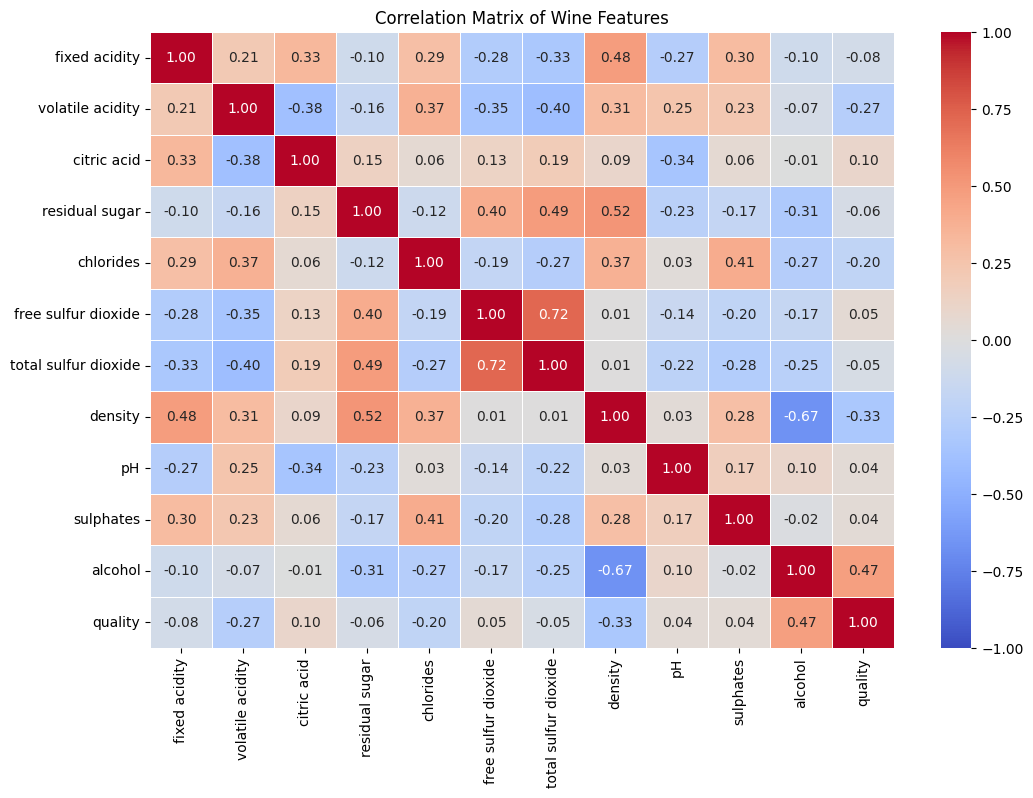

In [18]:
# Compute correlation matrix (excluding 'wine_type')
corr_matrix = df_combined.drop(columns=['wine_type']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix of Wine Features")
plt.show()

**Since alcohol has a lower density than water, it is expected that these two variables exhibit a strong negative correlation. In addition to this, the most significant positive correlation was observed between free sulfur dioxide and total sulfur dioxide, which is logical as they both measure sulfur dioxide content, just in different forms. Density also showed a positive correlation with both fixed acidity and residual sugar, though these relationships were not as strong as the previously mentioned ones. Additionally, total sulfur dioxide displayed a weak positive correlation with residual sugar. Beyond these key connections, the correlation heatmap did not reveal any other relationships exceeding a correlation coefficient of 0.5.**

### PCA (Principal Component Analysis)

In [19]:
# Exclude 'quality' and 'wine_type' columns (we don't want to scale categorical variables)
features = df_combined.drop(columns=['quality', 'wine_type'])

# Standardize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

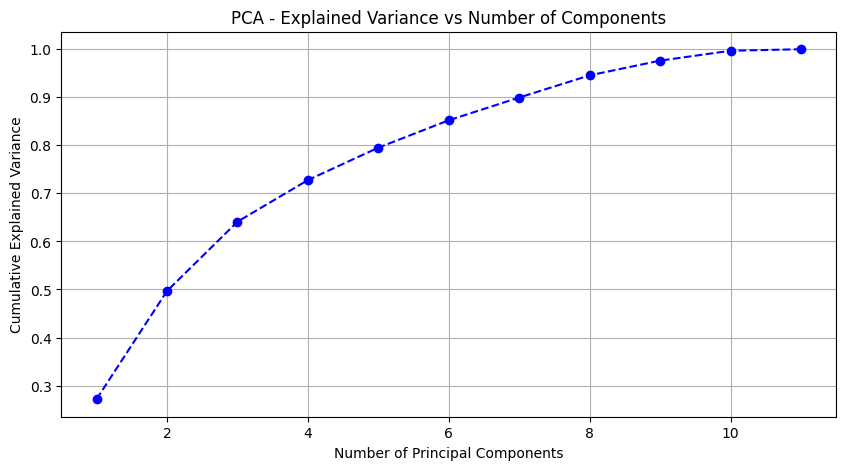

In [20]:
# Apply PCA
pca = PCA()
principal_components = pca.fit_transform(scaled_features)

# Explained variance ratio
explained_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot explained variance to choose optimal components
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance vs Number of Components")
plt.grid()
plt.show()

In [21]:
# Get explained variance ratio per component
explained_variance_ratio = pca.explained_variance_ratio_

# Print explained variance per component
for i, variance in enumerate(explained_variance_ratio):
    print(f"Principal Component {i+1}: {variance:.4f} ({variance*100:.2f}% of total variance)")

Principal Component 1: 0.2717 (27.17% of total variance)
Principal Component 2: 0.2250 (22.50% of total variance)
Principal Component 3: 0.1443 (14.43% of total variance)
Principal Component 4: 0.0867 (8.67% of total variance)
Principal Component 5: 0.0675 (6.75% of total variance)
Principal Component 6: 0.0570 (5.70% of total variance)
Principal Component 7: 0.0474 (4.74% of total variance)
Principal Component 8: 0.0461 (4.61% of total variance)
Principal Component 9: 0.0306 (3.06% of total variance)
Principal Component 10: 0.0205 (2.05% of total variance)
Principal Component 11: 0.0032 (0.32% of total variance)


**The PCA analysis revealed that the first two principal components account for nearly 50% of the total variance in the dataset, with PC1 explaining 27.17% and PC2 explaining 22.50%. This suggests that much of the data's variability can be captured within just these two components. PC3 contributes an additional 14.43%, while subsequent components explain progressively smaller portions of variance, with PC11 contributing only 0.32%. The diminishing variance explained by later components indicates that the dataset can likely be effectively reduced to a lower-dimensional representation without significant information loss, potentially improving computational efficiency while retaining most of the underlying structure.**

### Mutual Information

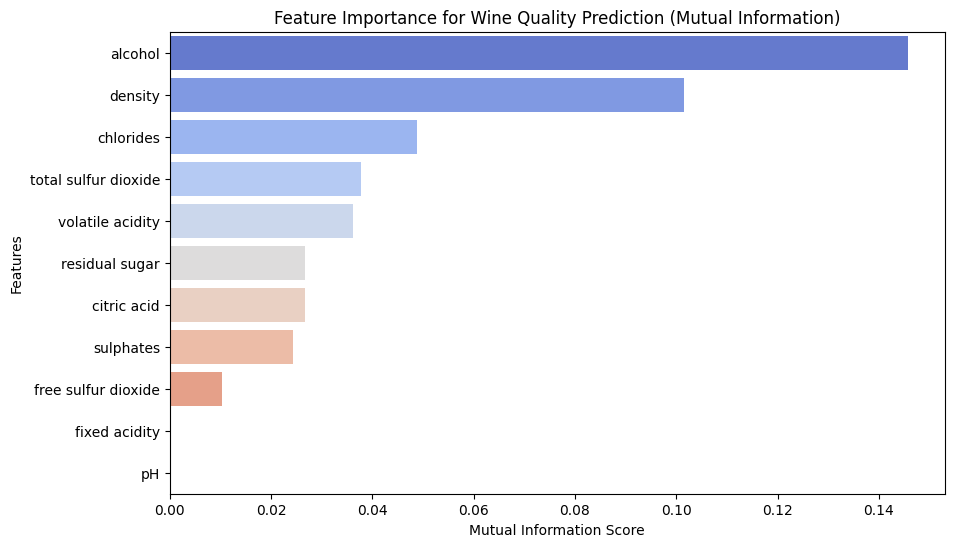

In [22]:
# Define feature set X and target variable y
X = df_combined.drop(columns=['quality', 'wine_type'])  # Excluding target variable
y = df_combined['quality']

# Compute Mutual Information scores
mi_scores = mutual_info_regression(X, y, random_state=42)

# Create DataFrame for visualization
mi_scores_df = pd.DataFrame({'Feature': X.columns, 'Mutual Information': mi_scores})
mi_scores_df = mi_scores_df.sort_values(by='Mutual Information', ascending=False)

# Plot results
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual Information', y='Feature', data=mi_scores_df, hue='Feature', palette="coolwarm", legend=False)
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Feature Importance for Wine Quality Prediction (Mutual Information)")
plt.show()

**I chose to create a mutual information plot as it provides a clear and quantitative way to identify which features have the greatest influence on wine quality. It should be noted that rerunning this code will give slightly different outputs each time. Subsequent analysis is based on one run. The plot highlights density and alcohol as the most impactful factors, which aligns with their strong correlation. In wine tasting, high alcohol levels and low density can reduce complexity, suppress aromas, and mute flavors, ultimately leading to a lower quality score. Total sulfur dioxide, which represents the total concentration of sulfur dioxide in the wine, is another significant factor. While low to moderate levels help preserve freshness, excessive amounts can introduce a harsh, chemical-like taste that overshadows the wine’s character. Residual sugar, the fourth most important feature, plays a crucial role in balancing sweetness—ensuring that the wine is neither too dry nor overly sweet. Lastly, chlorides, which correspond to salt content, influence both taste and mouthfeel, subtly affecting the overall perception of the wine.**

### Seaborn Plots

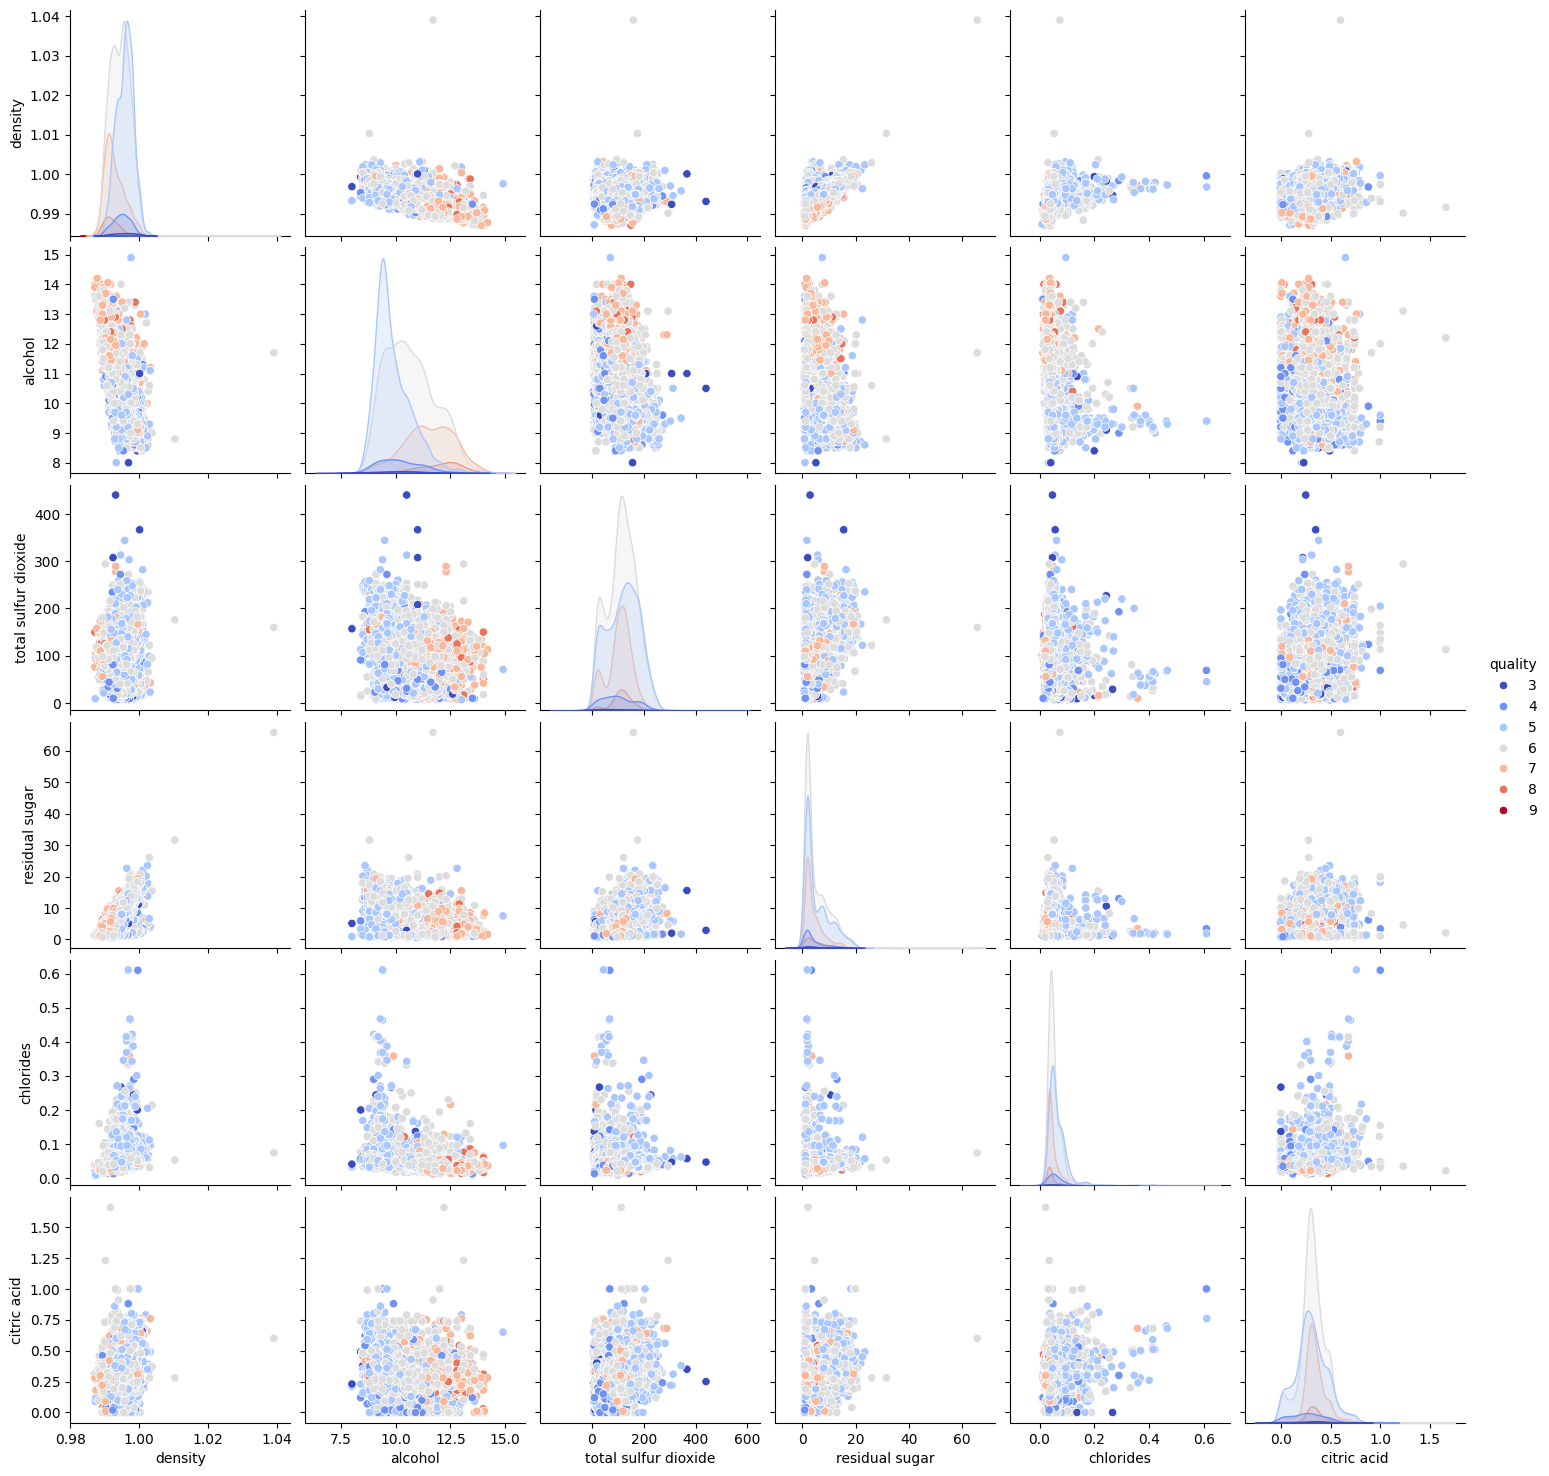

In [23]:
# Define the selected features for visualization
selected_features = ["density", "alcohol", "total sulfur dioxide", "residual sugar", 'chlorides', 'citric acid']

# Pairplot to visualize distributions and relationships
sns.pairplot(df_combined, vars=selected_features, hue="quality", palette="coolwarm", diag_kind="kde")
plt.show()

**Since I am working with 11 dimensions of data, the original seaborn plot was far too overwhelming. Thus, I chose to create them based on the 6 most important features of my mutual information analysis. We observe the same trends I discussed in the correlation heat map analysis. However, these plots allow us to see where higher scores lie in each pair. For example, alcohol of 12.5% with citric acid levels of about 0.25 have the strongest scores. Additionally, low residual sugar and low density values also seem to have stronger scores. These connections are interesting, and will be useful for later analysis.**

### CDF (Cumulative Distribution Function)

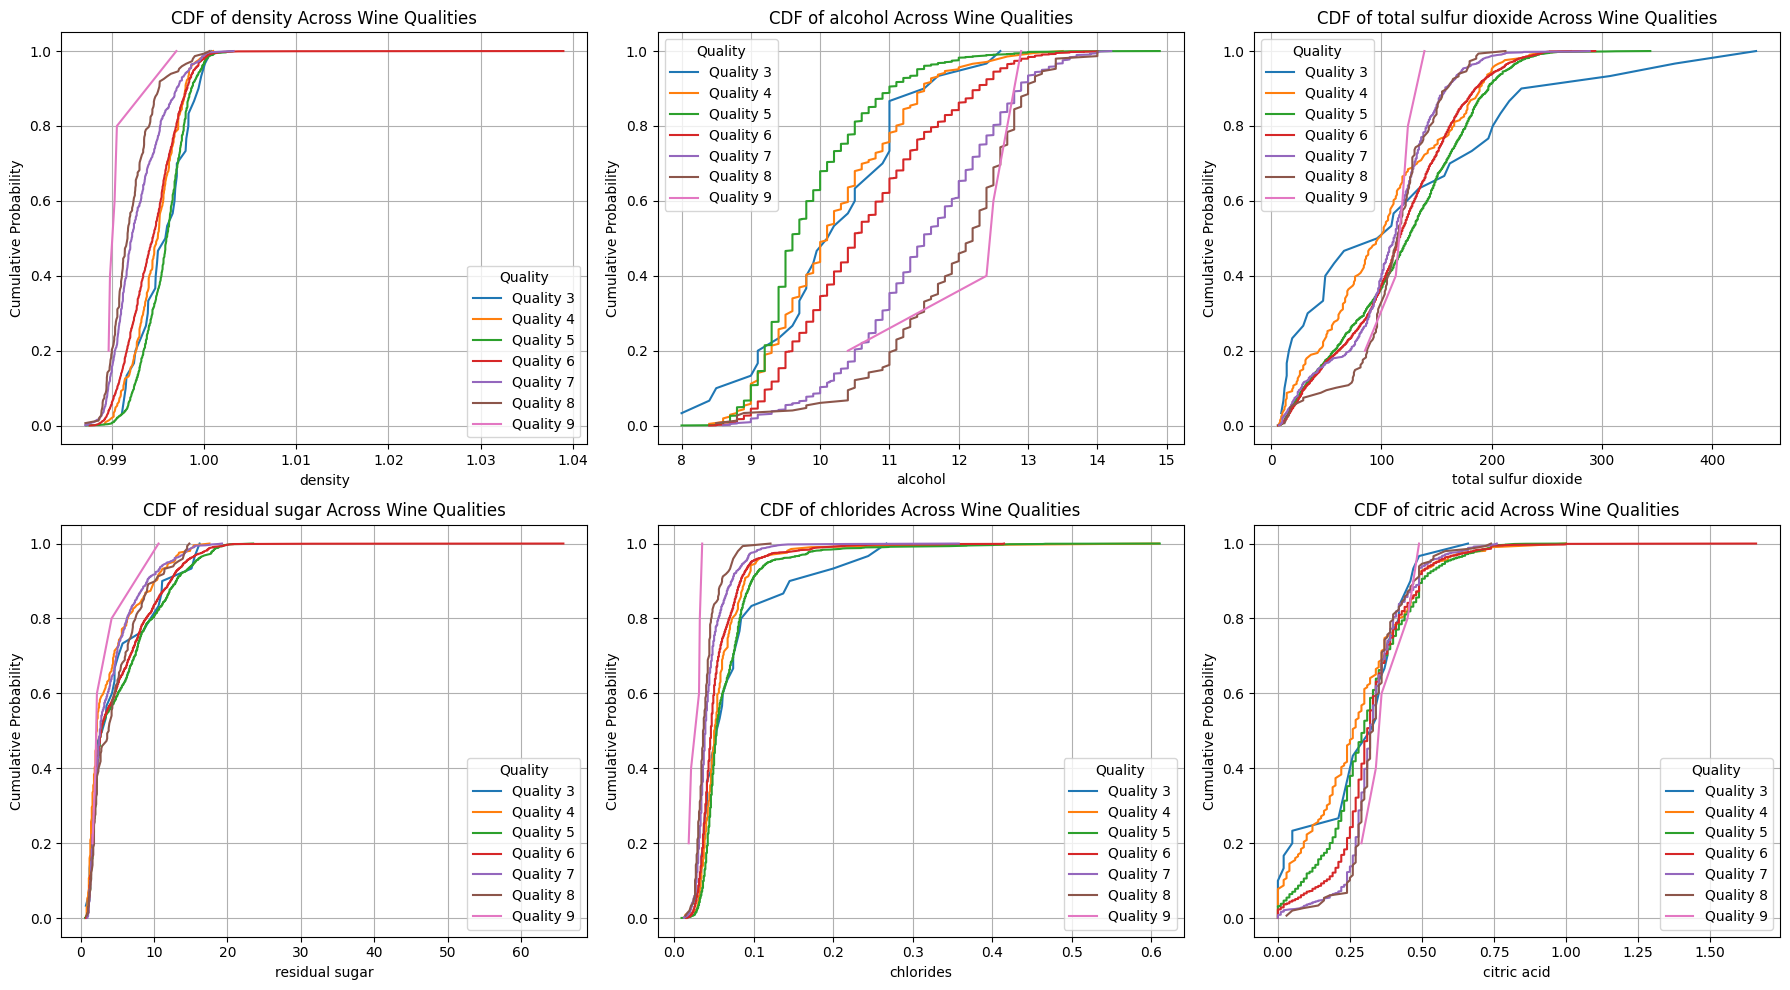

In [24]:
# Create subplots: 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(18, 10))  # Adjusted figsize for better spacing

# Loop through the selected features and plot their CDFs
for i, feature in enumerate(selected_features):
    ax = axes[i // 3, i % 3]  # Select the subplot position
    for quality in sorted(df_combined['quality'].unique()):
        subset = df_combined[df_combined['quality'] == quality]
        sorted_values = np.sort(subset[feature])
        cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
        ax.plot(sorted_values, cdf, label=f'Quality {quality}')

    # Formatting
    ax.set_xlabel(feature)
    ax.set_ylabel("Cumulative Probability")
    ax.set_title(f"CDF of {feature} Across Wine Qualities")
    ax.legend(title="Quality")
    ax.grid()

# Adjust layout
plt.tight_layout()
plt.show()

**Given the high dimensionality of this dataset, I have chosen to focus my analysis on the most influential features identified in the mutual information analysis. For alcohol content, higher-quality wines (scores of 6 and above) tend to have values concentrated between 11% and 12%, while lower-quality wines (scores of 5 and below) generally exhibit lower alcohol levels. Density also plays a role, with wines having densities above 0.99 generally receiving higher scores. Additionally, lower chloride and residual sugar content are associated with higher-quality wines. The total sulfur dioxide distribution is widest for wines with a quality score of 3, whereas most other wines cluster around 100 mg/L. Citric acid content does not show significant variation across quality levels, as its distribution remains fairly consistent. Among all features, alcohol content displays the broadest range of distributions and exhibits the most distinct differences between quality scores, making it a key factor in wine quality assessment.**